# Tutorial de uso de PyTorch para a implementación de redes neuronais

[PyTorch](https://pytorch.org/) é un *framework* para crear e adestrar redes neuronais artificiais. Ten multitude de módulos nos que se implementan as distintas partes dunha rede (capas, funcións de activación...), algorimos para actualizar intelixentemente os pesos das redes (optimizadores), funcións de perda, métricas de rendemento, etc.

Ademais, existen paquetes baseados en PyTorch que traballan con tipos de datos ou problemas específicos: [torchvision](https://pytorch.org/vision/stable/index.html) (para imaxes e vídeos), [torchaudio](https://pytorch.org/audio/stable/index.html) (para audio), [torchrl](https://pytorch.org/rl) (para sistemas de aprendizaxe por reforzo), e moitos outros.

Neste titorial, imos traballar cun problema de clasificación de imaxes, desde tres aproximacións diferentes:
1. Utilizando un perceptrón multicapa con tantas neuronas de entrada como píxeles teñan as imaxes.
2. Utilizando un descriptor de características tradicional para resumir a información das imaxes e logo procesar ditas características con un perceptrón multicapa.
3. Utilizando unha rede neuronal convolucional que extraia automaticamente as mellores características.

## Pasos iniciais

### Importación dos paquetes necesarios

Importamos o paquete torch (para implementación de redes neuronais) e o paquete torchvision (que implementa métodos orientados ao procesamento de imaxes). En caso de que non estean instalados, instalámolos no sistema.

Tamén importamos o paquete matplotlib para realizar representacións gráficas.

In [1]:
try:
    import torch
    from torch.utils.data import DataLoader
    from torchvision import datasets
    from torchvision.transforms import ToTensor
    import torch.nn as nn
    import torch.nn.functional as F
except ImportError:
    !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

try:
    from skimage.feature import hog
    from skimage.color import rgb2gray
except ImportError:
    !pip3 install scikit-image

import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix
import numpy as np
import random
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

torch.manual_seed(1)
random.seed(1)
np.random.seed(1)


### Funcións auxiliares

Imos definir algunhas funcións auxiliares que empregaremos máis adiante.

In [2]:
def plot_data_dist(training_labels, test_labels, labels_map):
    c_train = Counter(training_labels)
    class_freq_train = dict(c_train)

    c_test = Counter(test_labels)
    class_freq_test = dict(c_test)

    plt.figure(figsize=(10, 3))
    width = 0.4 
    train_keys = list(class_freq_train.keys())
    test_keys = [key + width for key in class_freq_test.keys()]

    plt.bar(train_keys, class_freq_train.values(), width=width, color='b', align='center', label='Adestramento')
    plt.bar(test_keys, class_freq_test.values(), width=width, color='r', align='center', label='Test')

    plt.xticks([key + width / 2 for key in class_freq_train.keys()], labels_map.values(), rotation='vertical')
    plt.ylabel('Frecuencia')
    plt.xlabel('Categoría')
    plt.legend()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels_map):
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 10))
    plt.imshow(conf_matrix_normalized, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, labels_map.values(), rotation=45)
    plt.yticks(tick_marks, labels_map.values())

    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, f"{conf_matrix[i, j]}", 
                    horizontalalignment="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")

    plt.ylabel('Clase real')
    plt.xlabel('Clase predicida')
    plt.show()

def get_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Descarga do dataset MNIST

Neste titorial imos utilizar o conxunto Fashion MNIST. É un conxunto de 70.000 imaxes (60.000 para adestrar e 10.000 para o test) de 28x28 pixeles, correspondentes a prendas de roupa. O obxectivo é clasificar as imaxes nunha das seguintes categorías:

- Camisola
- Pantalón
- Xersei
- Vestido
- Abrigo
- Sandalia
- Camisa
- Deportiva
- Bolso
- Botín

Para traballar en PyTorch necesitamos almacenar o conxunto de datos nun obxecto [Dataset]. Como o Fashion MNIST xa está integrado en PyTorch, tan só temos que importalo cos seguintes comandos, que descargan automaticamente as imaxes de adestramento e de test e as empaquetan en sendos obxectos de tipo [Dataset].

[Dataset]: https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset

In [3]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.9MB/s]


Como o conxunto de adestramento é bastante grande e pode ralentizar o proceso, imos quedarnos con un subconxunto aleatorio de 30.000 imaxes

In [4]:
training_data, _ = torch.utils.data.random_split(training_data, [30000, 30000])

Ahora imos representar a frecuencia de cada categoría para os conxuntos de adestramento e de test.

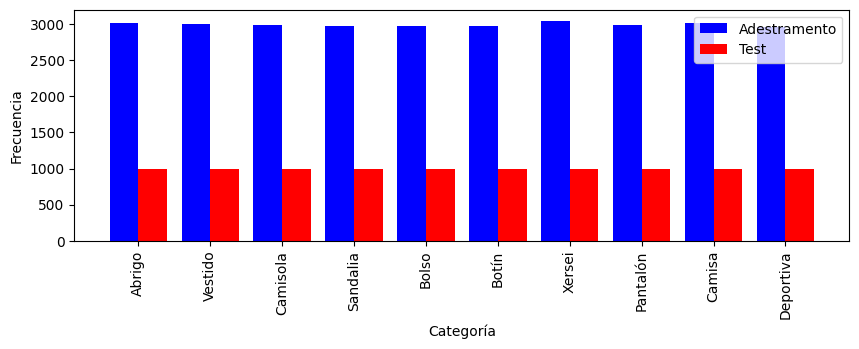

In [5]:
labels_map = {
    0: "Camisola",
    1: "Pantalón",
    2: "Xersei",
    3: "Vestido",
    4: "Abrigo",
    5: "Sandalia",
    6: "Camisa",
    7: "Deportiva",
    8: "Bolso",
    9: "Botín",
}

labels_training = [label for _, label in training_data]
labels_test = [label for _, label in test_data]
plot_data_dist(labels_training, labels_test, labels_map)

Vemos que o conxunto está perfectamente balanceado (aproximadamente 3.000 de cada categoría para o conxunto de adestramento e 1.000 de cada categoría para o conxunto de test). Ahora visualizamos unhas poucas imaxes do conxunto para ver que aspecto teñen.

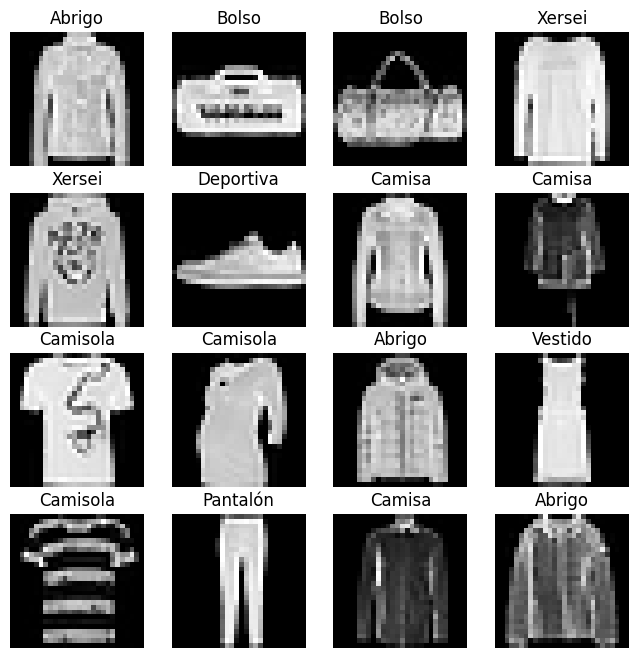

In [6]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 4, 4
for i in range(1, cols * rows + 1):
    # Mostreamos unha imaxe aleatoria
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Creación de *Dataloaders*

O adestramento das redes neuronais é un proceso iterativo onde se lle van ensinando "exemplos" á rede para que esta aprenda dos seus erros e axuste os seus pesos. Sen embargo, cando traballamos con grandes conxuntos de datos, non podemos procesar todas as imaxes do conxunto á vez, senon que temos que procesalas individualmente ou en grupos pequenos chamados lotes (ou *batches*). Cando a rede neuronal procesa todos os lotes do conxunto de adestramento, dicimos que realizou unha época (*epoch*). O número de épocas a realizar durante o adestramento pódese configurar polo usuario.

Para automatizar este proceso iterativo, PyTorch ofrécenos os obxectos da clase [DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader). Á hora de crear un *DataLoader*, o máis importante é indicarlle o conxunto de datos que vai utilizar (*dataset*), cantas imaxes vai conter cada lote (*batch_size*) e se os lotes se van barallar ao comezo de cada época (*shuffle*).

In [7]:
batch_size = 8
train_dataloader = DataLoader(dataset=training_data,
                              batch_size=batch_size,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=batch_size,
                             shuffle=True)

Estes *dataloaders* pódense percorrer con un bucle *for*, obtendo en cada iteración un lote de imaxes. Neste caso, o lote inclúe as imaxes por un lado (*batch_imgs*) e as etiquetas reais de cada imaxe (a súa clase) por outro (*batch_labels*). Imos probar a percorrer o primeiro lote de adestramento.

In [8]:
for batch_imgs, batch_labels in train_dataloader:
    print(f"Tamaño das imaxes: {batch_imgs.size()} - Etiquetas: {batch_labels}")
    break # Paramos o bucle, xa que só queremos ver un lote

Tamaño das imaxes: torch.Size([8, 1, 28, 28]) - Etiquetas: tensor([7, 8, 5, 4, 8, 1, 4, 7])


Como vemos, as imaxes de cada lote en PyTorch almacénanse nun array multidimensional (tamén chamado tensor) co formato `[tamaño_lote,canais,filas,columnas]`, polo que no exemplo anterior o lote ten 8 imaxes de 1 canle (escala de grises) de tamaño 28x28 píxeles. Poderíamos, por exemplo, acceder á cuarta fila da segunda imaxe do lote mediante `batch_imgs[1,0,3,:]`. Por outra banda, as etiquetas veñen nun array de `tamaño_lote` elementos, no que cada elemento é o código da categoría á que pertence cada imaxe do lote: 0 para camisola, 1 para pantalón, etc.

## Aproximaxión 1: MLP con imaxes en crudo

Ahora imos ver como se crea unha rede neuronal sinxela (de tipo perceptrón multicapa), con 2 capas ocultas de 512 neuronas. A capa de entrada terá tantas neuronas como píxeles teña unha imaxe e a capa de saída terá tantas neuronas como clases teña o problema, é dicir, 10.

Para que a rede neuronal obteña unha distribución de probabilidade (é dicir, que para calquera instancia as probabilidades obtidas para cada categoría sumasen 1) sería preciso engadir a operación *softmax* ao final. Porén, a función de perda que utilizaremos xa "tén integrada" a función *softmax*, co cal non a incluiremos na arquitectura da rede.

In [14]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super(SimpleMLP, self).__init__()
        # A capa Flatten convirte unha imaxe nun tensor unidimensional de 28x28=784 píxeles
        self.flatten = nn.Flatten()
        # A capa de tipo Sequential é unha secuencia de módulos (capas) que se aplican en orde
        self.linear_relu_stack = nn.Sequential(
            # Capa oculta 1: 784 valores de entrada e 128 valores de saída (porque tén 128 neuronas)
            nn.Linear(input_size, 128),
            # Función de activación ReLU (deixa pasar os valores positivos e pon a cero os negativos)
            nn.ReLU(),
            # Capa oculta 2: 128 valores de entrada e 128 de saída
            nn.Linear(128, 128),
            # Función de activación ReLU (deixa pasar os valores positivos e pon a cero os negativos)
            nn.ReLU(),
            # Capa de saída: 128 valores de entrada e 10 de saída (un por cada clase)
            nn.Linear(128, output_size),
            # Función de activación Softmax (transforma os valores de saída nunha distribución de probablidade que suma 1)
            # nn.Softmax(dim=1)
        )

    # Definimos o método forward, que é chamado cando se pasa unha imaxe pola rede
    def forward(self, x):
        # Aplicamos o aplanamento
        x = self.flatten(x)
        # Aplicamos as capas secuenciais
        predicted_probs = self.linear_relu_stack(x)
        return predicted_probs
    
mlp = SimpleMLP(input_size=28*28, output_size=10)
print(mlp)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


Obtemos o número de parámetros adestrables do modelo

In [15]:
print(f"O modelo MLP ten {get_parameters(mlp):,} parámetros")

O modelo MLP ten 118,282 parámetros


Probamos a executar este modelo (todavía sen adestrar) sobre o primeiro lote de imaxes obtido antes.

In [16]:
predicted_probs = mlp(batch_imgs)
print(f"Tamaño das predicións: {predicted_probs.shape}")
# Probabilidades obtidas para a primeira imaxe
predicted_probs1 = predicted_probs[0]
print(f"Primeira predición: {predicted_probs1}")
# Para obter unha distribución de probabilidade, aplicamos a función Softmax
predicted_probs1 = F.softmax(predicted_probs1, dim=0)
print(f"Primeira predición (tras Softmax): {predicted_probs1}")
# Comprobamos que a suma das probabilidades é 1
print(f"Suma das probabilidades: {torch.sum(predicted_probs1)}")
# Obtemos a categoría coa maior probabilidade
pred_label = torch.argmax(predicted_probs1)
# Podemos extraer o elemento dun tensor coa función item()
pred_label = pred_label.item()
print(f"Clase predita: {pred_label} ({labels_map[pred_label]})")

Tamaño das predicións: torch.Size([8, 10])
Primeira predición: tensor([-0.0853, -0.0560,  0.0075,  0.0230, -0.0450, -0.0020,  0.0378,  0.0057,
        -0.1555,  0.0785], grad_fn=<SelectBackward0>)
Primeira predición (tras Softmax): tensor([0.0934, 0.0962, 0.1025, 0.1041, 0.0972, 0.1015, 0.1056, 0.1023, 0.0871,
        0.1100], grad_fn=<SoftmaxBackward0>)
Suma das probabilidades: 1.0
Clase predita: 9 (Botín)


Como vemos, o tamaño da saída é `[tamaño_lote, número_categorías], é dicir, para cada imaxe do lote temos a probabilidade de que pertenza a cada categoría concreta. A suma das probabilidades é 1, grazas a que aplicamos unha función *softmax* á saída da rede.

Imos empezar a preparar o adestramento desta rede. Primeiro, configuramos os hiperparámetros necesarios (que podemos variar nun futuro): a función de perda (que intentaremos minimizar), a taxa de aprendizaxe (*learning rate*), o optimizador (o mecanismo que decide como se axustan os pesos da rede) e o número de iteracións (épocas ou *epochs*).

In [17]:
loss_fn = nn.CrossEntropyLoss()

learning_rate = 1e-3
optimizer = torch.optim.SGD(mlp.parameters(), lr=learning_rate)

epochs = 20

Ahora implementamos as funcións para adestrar e testar o modelo. Cabe destacar que na función de test, á hora de obter a métrica de *accuracy*, tampouco aplicamos a función *softmax* ao vector de valores obtidos pola rede. Isto é así porque o único que nos interesa é ver a que categoría se lle asigna a maior probabilidade, é dicir, a posición onde está o valor máximo deste vector. Esta posición vai ser a mesma apliquemos *softmax* ou non.

In [18]:
def train(dataloader, model, loss_fn, optimizer):
    # Obtemos o número total de lotes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de adestramento
    model.train()
    # Iteramos sobre os lotes
    n_batch = 0
    for batch_imgs, batch_labels in dataloader:
        # Obtemos as predicións para o lote actual
        batch_predicted_probabilities = model(batch_imgs)
        # Calculamos a perda
        loss = loss_fn(batch_predicted_probabilities, batch_labels)
        # Poñemos a cero os gradientes dos parámetros do modelo
        optimizer.zero_grad()
        # Realizamos a retropropagación para calcular os gradientes de cada parámetro
        loss.backward()
        # Actualizamos os parámetros do modelo utilizando os gradientes calculados
        optimizer.step()

        # Cada 100 lotes, imprimimos a perda e o progreso
        if n_batch % 100 == 0:
            loss, imgs_processed = loss.item(), n_batch * len(batch_imgs)
            print(f"perda: {loss:>7f}  [{imgs_processed:>5d}/{num_images:>5d}]")

        n_batch += 1

    return loss

def test(dataloader, model):
    # Obtemos o número total de imaxes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de avaliación (sen calcular gradientes)
    model.eval()
    # Inicializamos as variables para gardar a perda e a precisión
    test_loss, correct = 0, 0
    # Inicializamos as listas para gardar as clases predicidas e as clases reais
    test_predicted_classes, test_true_classes = [], []
    with torch.no_grad():
        for batch_imgs, batch_labels in dataloader:
            # Obtemos as predicións para o lote actual
            batch_predicted_probabilities = model(batch_imgs)
            # Calculamos a perda e acumulamos o valor
            test_loss += loss_fn(batch_predicted_probabilities, batch_labels).item()
            # Calculamos as clases predicidas (aquelas con maior probabilidade)
            batch_predicted_classes = batch_predicted_probabilities.argmax(dim=1)
            # Obtemos o número de predicións correctas e acumulamos o valor
            correct += (batch_predicted_classes == batch_labels).sum().item()
            # Gardamos as clases predicidas e as clases reais. Precisamos convertelas a listas de Python coa función tolist()
            test_predicted_classes.extend(batch_predicted_classes.tolist())
            test_true_classes.extend(batch_labels.tolist())
    # Calculamos a perda media e o porcentaxe de predicións correctas (accuracy), dividindo entre o número total de imaxes 
    test_loss /= num_images
    correct /= num_images
    print(f"Perda media: {test_loss:>8f} Accuracy: {correct*100:>0.1f}%\n")

    return test_predicted_classes, test_true_classes

Ahora executamos o bucle de adestramento e o test

In [14]:
train_losses_mlp = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train(train_dataloader, mlp, loss_fn, optimizer)
    train_losses_mlp.append(train_loss.item())

test_predicted_classes_mlp, test_true_classes_mlp = test(test_dataloader, mlp)

Epoch 1
-------------------------------
perda: 2.299192  [    0/30000]
perda: 2.288604  [  800/30000]
perda: 2.291483  [ 1600/30000]
perda: 2.225563  [ 2400/30000]
perda: 2.220149  [ 3200/30000]
perda: 2.241306  [ 4000/30000]
perda: 2.228775  [ 4800/30000]
perda: 2.219912  [ 5600/30000]
perda: 2.227369  [ 6400/30000]
perda: 2.252094  [ 7200/30000]
perda: 2.115889  [ 8000/30000]
perda: 2.136985  [ 8800/30000]
perda: 2.235647  [ 9600/30000]
perda: 2.110562  [10400/30000]
perda: 2.155792  [11200/30000]
perda: 1.978591  [12000/30000]
perda: 2.062443  [12800/30000]
perda: 2.018642  [13600/30000]
perda: 1.956493  [14400/30000]
perda: 1.878581  [15200/30000]
perda: 1.868371  [16000/30000]
perda: 1.858669  [16800/30000]
perda: 1.868006  [17600/30000]
perda: 1.868634  [18400/30000]
perda: 2.010569  [19200/30000]
perda: 1.704606  [20000/30000]
perda: 1.646989  [20800/30000]
perda: 1.569073  [21600/30000]
perda: 1.712178  [22400/30000]
perda: 1.608339  [23200/30000]
perda: 1.933138  [24000/30000]

Podemos representar gráficamente as perdas no adestramento para ver que, efectivamente, o modelo aprende.

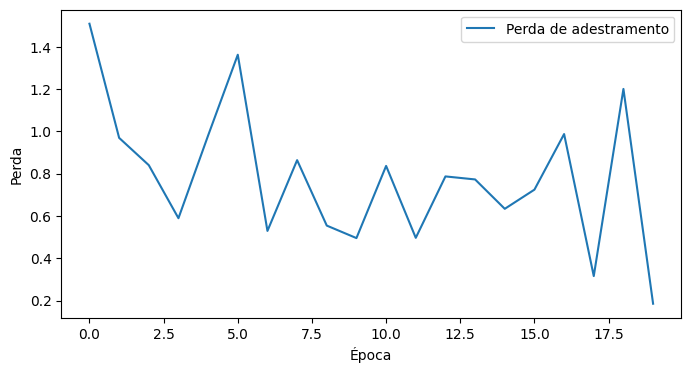

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_mlp, label='Perda de adestramento')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.show()

Representamos tamén a matriz de confusión de test

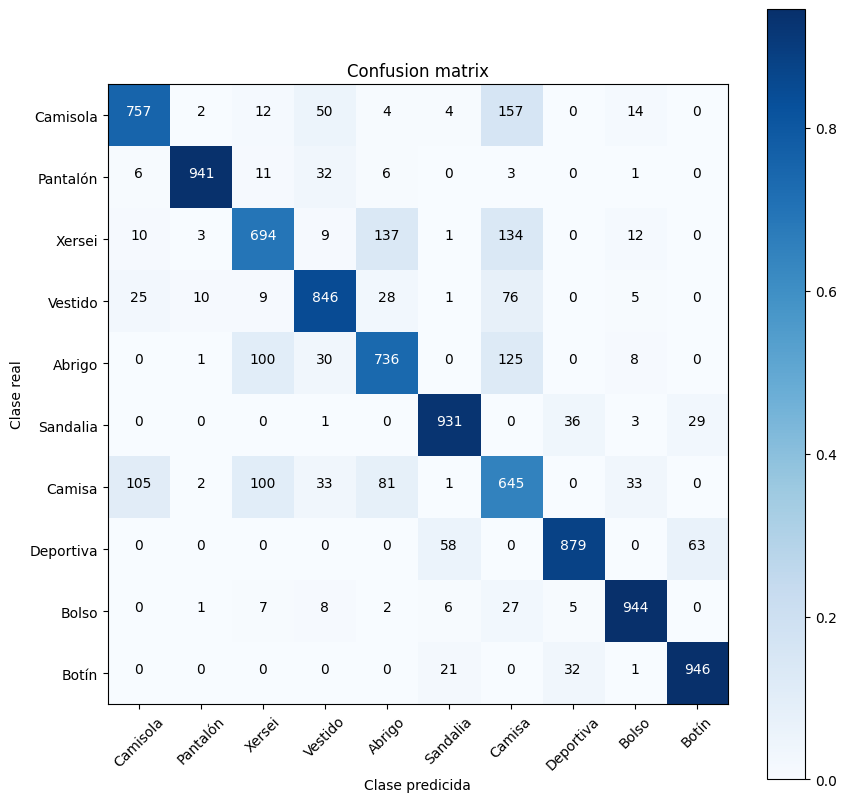

In [16]:
plot_confusion_matrix(y_true=test_true_classes_mlp, y_pred=test_predicted_classes_mlp, labels_map=labels_map)

## Aproximación 2: MLP a partir de características extraídas manualmente

Con este enfoque pretendemos resumir a información contida nunha imaxe de 28x28 píxeles (784 valores) nun vector de características dun tamaño moito menor, mediante o cal reduciremos a redundancia de información (píxeles veciños son moi parecidos). Isto repercutirá en que o MLP utilizado posterioremente terá unha capa de entrada de moitas menos neuronas, polo que requirirá un adestramento de moitos menos parámetros.

In [17]:
def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(img[0], pixels_per_cell=(8, 8), cells_per_block=(2, 2), feature_vector=True)
        hog_features.append(features)
    return np.array(hog_features, dtype=np.float32)

class SimpleMLPWithHOG(nn.Module):
    def __init__(self, input_size, output_size):
        super(SimpleMLPWithHOG, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_size),
        )

    def forward(self, x):
        # Apply HOG feature extraction
        hog_features = extract_hog_features(x)
        # Convert to tensor
        hog_features = torch.from_numpy(hog_features)
        # Apply MLP
        x = self.flatten(hog_features)
        predicted_probs = self.linear_relu_stack(x)
        return predicted_probs

    
hog_mlp = SimpleMLPWithHOG(input_size=144, output_size=10)

In [18]:
loss_fn = nn.CrossEntropyLoss()

learning_rate = 1e-3
optimizer = torch.optim.SGD(hog_mlp.parameters(), lr=learning_rate)

epochs = 20

In [19]:
print(f"O modelo MLP con HOG ten {get_parameters(hog_mlp):,} parámetros")

O modelo MLP con HOG ten 36,362 parámetros


In [20]:
train_losses_feature_mlp = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train(train_dataloader, hog_mlp, loss_fn, optimizer)
    train_losses_feature_mlp.append(train_loss.item())

test_predicted_classes_feature_mlp, test_true_classes_feature_mlp = test(test_dataloader, hog_mlp)

Epoch 1
-------------------------------
perda: 2.305932  [    0/30000]
perda: 2.319255  [  800/30000]
perda: 2.294334  [ 1600/30000]
perda: 2.290675  [ 2400/30000]
perda: 2.264017  [ 3200/30000]
perda: 2.299672  [ 4000/30000]
perda: 2.283164  [ 4800/30000]
perda: 2.287747  [ 5600/30000]
perda: 2.328006  [ 6400/30000]
perda: 2.330934  [ 7200/30000]
perda: 2.313240  [ 8000/30000]
perda: 2.314462  [ 8800/30000]
perda: 2.298262  [ 9600/30000]
perda: 2.311522  [10400/30000]
perda: 2.277678  [11200/30000]
perda: 2.304317  [12000/30000]
perda: 2.297958  [12800/30000]
perda: 2.305207  [13600/30000]
perda: 2.266135  [14400/30000]
perda: 2.272179  [15200/30000]
perda: 2.303033  [16000/30000]
perda: 2.301069  [16800/30000]
perda: 2.281995  [17600/30000]
perda: 2.295017  [18400/30000]
perda: 2.292159  [19200/30000]
perda: 2.280895  [20000/30000]
perda: 2.270959  [20800/30000]
perda: 2.295062  [21600/30000]
perda: 2.282227  [22400/30000]
perda: 2.279393  [23200/30000]
perda: 2.293159  [24000/30000]

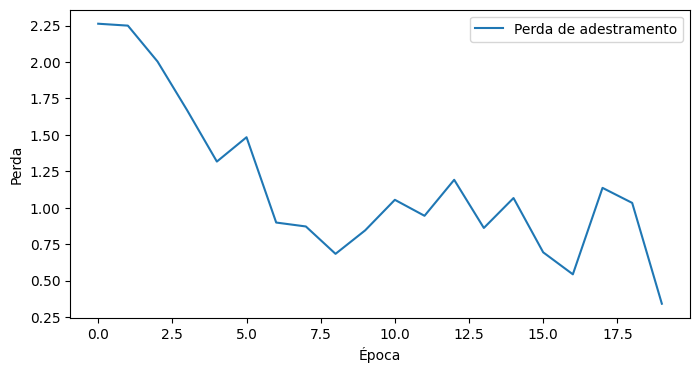

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_feature_mlp, label='Perda de adestramento')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.show()

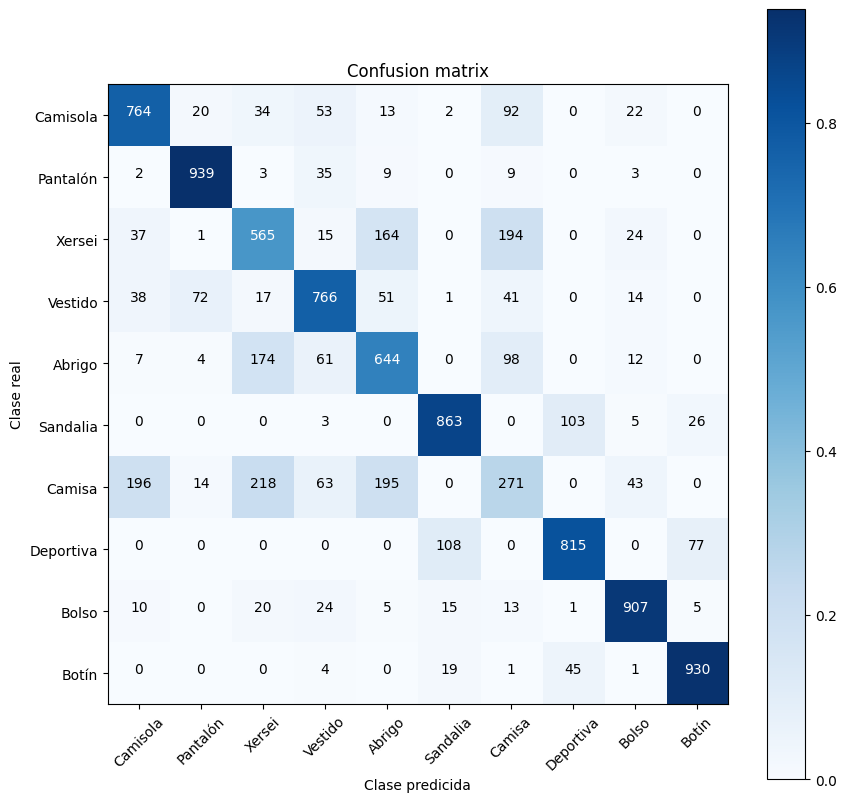

In [22]:
plot_confusion_matrix(y_true=test_true_classes_feature_mlp, y_pred=test_predicted_classes_feature_mlp, labels_map=labels_map)

## Aproximación 3: CNN

Podemos crear unha rede neuronal convolucional do mesmo xeito que unha MLP (é dicir, creando unha clase que herda da superclase Module). Neste caso a nosa CNN terá dúas capas convolucionais (con 32 e 64 canais de saída, respectivamente), unha capa totalmente conectada de 128 valores de saída, e unha capa de saída con 10 valores, un por cada categoría.

De novo, non aplicamos a función *softmax* para utilizar a mesma función de perda que coa rede MLP.

In [19]:
class ConvNet(nn.Module):

    def __init__(self, in_channels=1, num_classes=10):
        super(ConvNet, self).__init__()
        # Primeira capa convolucional
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=3, stride=1, padding=1)
        # Capa de max pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        # Capa de activación ReLU
        self.relu = nn.ReLU()
        # Segunda capa convolucional
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        # Capa de aplanamento
        self.flatten = nn.Flatten()
        # Capa totalmente conectada
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(32*7*7, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        
        x = self.flatten(x)
        x = self.linear_relu_stack(x)
        return x
    
cnn = ConvNet()

Obtemos o número de parámetros da CNN

In [20]:
print(f"O modelo ten {get_parameters(cnn):,} parámetros")

O modelo ten 30,074 parámetros


Configuramos os hiperparámetros de adestramento, que serán os mesmos que os empregados co MLP.

In [21]:
loss_fn = nn.CrossEntropyLoss()

learning_rate = 1e-3
optimizer = torch.optim.SGD(cnn.parameters(), lr=learning_rate)

epochs = 20

In [22]:
train_losses_cnn = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train(train_dataloader, cnn, loss_fn, optimizer)
    train_losses_cnn.append(train_loss.item())

test_predicted_classes_cnn, test_true_classes_cnn = test(test_dataloader, cnn)

Epoch 1
-------------------------------
perda: 2.344746  [    0/30000]
perda: 2.351259  [  800/30000]
perda: 2.274515  [ 1600/30000]
perda: 2.339463  [ 2400/30000]
perda: 2.279800  [ 3200/30000]
perda: 2.331805  [ 4000/30000]
perda: 2.287907  [ 4800/30000]
perda: 2.263082  [ 5600/30000]
perda: 2.304766  [ 6400/30000]
perda: 2.284115  [ 7200/30000]
perda: 2.255692  [ 8000/30000]
perda: 2.271006  [ 8800/30000]
perda: 2.249401  [ 9600/30000]
perda: 2.216706  [10400/30000]
perda: 2.152392  [11200/30000]
perda: 2.194161  [12000/30000]
perda: 2.208256  [12800/30000]
perda: 2.301836  [13600/30000]
perda: 2.137279  [14400/30000]
perda: 2.190264  [15200/30000]
perda: 2.139246  [16000/30000]
perda: 2.252726  [16800/30000]
perda: 1.976102  [17600/30000]
perda: 2.128154  [18400/30000]
perda: 2.145647  [19200/30000]
perda: 2.079575  [20000/30000]
perda: 2.294064  [20800/30000]
perda: 1.864152  [21600/30000]
perda: 2.023206  [22400/30000]
perda: 1.804974  [23200/30000]
perda: 2.007573  [24000/30000]

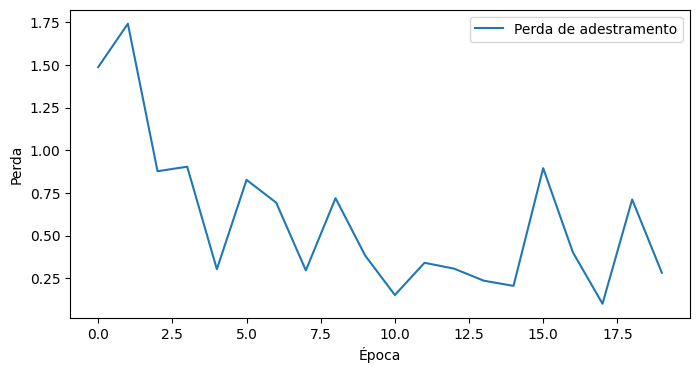

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_cnn, label='Perda de adestramento')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.show()

Amosamos a matriz de confusión obtida pola CNN

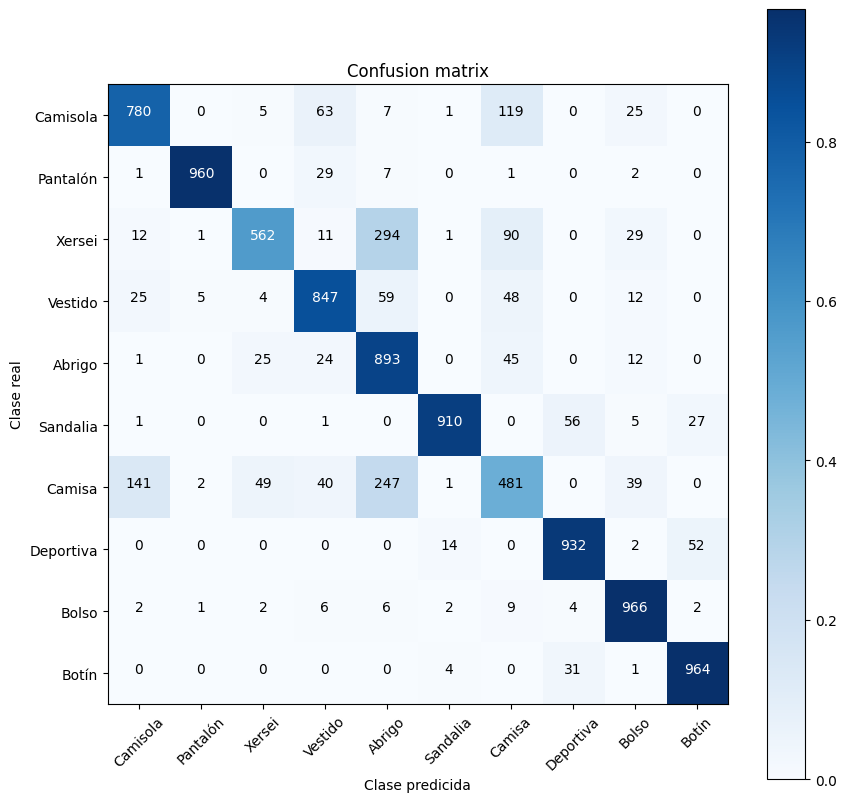

In [24]:
plot_confusion_matrix(y_true=test_true_classes_cnn, y_pred=test_predicted_classes_cnn, labels_map=labels_map)

Imos resumir os valores de *accuracy* e *F1*-medio obtidos por cada aproximación, tendo en conta o número de parámetros adestrables.

In [25]:
models = ['MLP', 'MLP + HOG', 'CNN']
accuracies = [accuracy_score(test_true_classes_mlp, test_predicted_classes_mlp), 
              accuracy_score(test_true_classes_feature_mlp, test_predicted_classes_feature_mlp), 
              accuracy_score(test_true_classes_cnn, test_predicted_classes_cnn)]
f1_scores = [f1_score(test_true_classes_mlp, test_predicted_classes_mlp, average='macro'),
            f1_score(test_true_classes_feature_mlp, test_predicted_classes_feature_mlp, average='macro'),
            f1_score(test_true_classes_cnn, test_predicted_classes_cnn, average='macro')]
parameters = [get_parameters(mlp), get_parameters(hog_mlp), get_parameters(cnn)]

df = pd.DataFrame({'Model': models, 'Accuracy': accuracies, 'F1': f1_scores, 'Parameters': parameters})
print(df)

NameError: name 'test_true_classes_mlp' is not defined

## Exercicio 1

Modifica a función *train* para que realice unha validación ao rematar cada época. Para elo realiza as seguintes tarefas:

1. Subdivide o conxunto actual de adestramento para reservar un 15% de imaxes para validar e o restante 85% para adestrar.
2. Crea un novo *Dataloader* para o conxunto de validación, e modifica o de adestramento para que só use o novo conxunto (85%).
3. Crea unha función que realice a validación do modelo. Podes usar a función *test*, xa que fai o mesmo, pero non te líes cos nomes. Almacena os valores de perda en validación nun array, do mesmo xeito que se fai con *train_losses*.
4. Almacena o valor menor de perda, así como o estado do modelo que obtén dito valor. Podes botarlle un ollo ao [titorial de Pytorch de gardado/carga de modelos](https://pytorch.org/tutorials/beginner/saving_loading_models.html): 
4. Implementa a funcionalidade de *Early Stopping*, é dicir, que o adestramento pare se a perda de validación non mellora (decrece) durante un número de épocas fixadas polo usuario.
5. Ao rematar o adestramento (ben porque se alcanzou o número máximo de épocas ou ben porque se fixo o *Early Stopping*), recuperar a versión do modelo que obtivese a menor perda en validación. Na gráfica da función de perda, podes representar a perda de adestramento fronte á perda de validación, o cal pode ser útil para detectar se o modelo está sobreaxustando.
6. Con esa mellor versión, facer o test e comparar os resultados obtidos (nas tres aproximacións) con respecto ao adestramento anterior (cun número fixo de épocas).

In [ ]:
def test_loss(dataloader, model, loss_fn):
    # Obtemos o número total de imaxes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de avaliación (sen calcular gradientes)
    model.eval()
    # Inicializamos as variables para gardar a perda e a precisión
    test_loss, correct = 0, 0
    # Inicializamos as listas para gardar as clases predicidas e as clases reais
    test_predicted_classes, test_true_classes = [], []
    with torch.no_grad():
        for batch_imgs, batch_labels in dataloader:
            # Obtemos as predicións para o lote actual
            batch_predicted_probabilities = model(batch_imgs)
            # Calculamos a perda e acumulamos o valor
            test_loss += loss_fn(batch_predicted_probabilities, batch_labels).item()
            # Calculamos as clases predicidas (aquelas con maior probabilidade)
            batch_predicted_classes = batch_predicted_probabilities.argmax(dim=1)
            # Obtemos o número de predicións correctas e acumulamos o valor
            correct += (batch_predicted_classes == batch_labels).sum().item()
            # Gardamos as clases predicidas e as clases reais. Precisamos convertelas a listas de Python coa función tolist()
            test_predicted_classes.extend(batch_predicted_classes.tolist())
            test_true_classes.extend(batch_labels.tolist())
    # Calculamos a perda media e o porcentaxe de predicións correctas (accuracy), dividindo entre o número total de imaxes 
    test_loss /= num_images
    correct /= num_images
    print(f"Perda media: {test_loss:>8f} Accuracy: {correct*100:>0.1f}%\n")

    return test_loss

In [ ]:
# Realiza nesta celda o exercicio anterior (non modifiques as celdas anteriores)
from sklearn.model_selection import train_test_split
import copy 
from torch.utils.data import DataLoader, random_split

train_losses_cnn = []
val_losses_cnn = []
epochs = 20
best_val_loss = float('inf')
best_model = None
patience = 3
current_patience = 0
#Dividir modelo en adestramento e validación 85-15
train_size = int(0.85 * len(training_data))  # 85% para entrenamiento
val_size = len(training_data) - train_size  # 15% para validación

train_dataset, val_dataset = random_split(training_data, [train_size, val_size])

# crear DataLoaders a partir dos datasets
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train(train_dataloader, cnn, loss_fn, optimizer)
    train_losses_cnn.append(train_loss.item())

    # Evaluar conxunto de val
    val_loss = test_loss(val_dataloader, cnn, loss_fn)
    val_losses_cnn.append(val_loss.item())

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(cnn.state_dict())
        current_patience = 0
    else:
        current_patience += 1
        if current_patience >= patience:
            print("Early stopping")
            break
cnn.load_state_dict(best_model)

test_predicted_classes_cnn, test_true_classes_cnn = test(test_dataloader, cnn)

perda: 0.110555  [17600/25500]
perda: 0.656456  [18400/25500]
perda: 0.078174  [19200/25500]
perda: 0.675556  [20000/25500]
perda: 0.553115  [20800/25500]


## Exercicio 2

Proba a engadir normalización por lotes á túa rede CNN. Para elo modifica a arquitectura, aplicando unha capa [BatchNorm2d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html) inmediatamente despois de cada capa convolucional.

In [ ]:
# Realiza nesta celda o exercicio anterior (non modifiques as celdas anteriores)